# 04 - Forecasting Model
Melatih model baseline (SARIMA) dan model Machine Learning (XGBoost) untuk memprediksi inflasi.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import os

## 1. Load Feature Dataset

In [ ]:
df_path = '../data/features/feature_dataset.csv'
df = pd.read_csv(df_path, parse_dates=['date'])
df = df.sort_values('date').dropna(subset=['inflation_yoy'])
display(df.head())

,date,pcpipch,inflation_yoy,lag_1_inflation,lag_2_inflation,lag_3_inflation,lag_6_inflation,lag_12_inflation,roll3_inflation_mean,roll6_inflation_mean,roll3_inflation_std,month_sin,month_cos,is_ramadan_month,is_lebaran_window,is_nataru,is_harvest_season,year,month
0,2010-01-01,5.1,5.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,0,0,1,0,2010,1
1,2010-02-01,5.1,5.1,5.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.866025,5.000000e-01,0,0,0,1,2010,2
2,2010-03-01,5.1,5.1,5.1,5.1,NaN,NaN,NaN,5.1,NaN,0.0,1.000000,6.123234e-17,1,0,0,1,2010,3
3,2010-04-01,5.1,5.1,5.1,5.1,5.1,NaN,NaN,5.1,NaN,0.0,0.866025,-5.000000e-01,1,1,0,0,2010,4
4,2010-05-01,5.1,5.1,5.1,5.1,5.1,NaN,NaN,5.1,NaN,0.0,0.500000,-8.660254e-01,0,1,0,0,2010,5


## 2. Train/Test Split
Split secara kronologis (Time Series Split).

In [ ]:
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Train range: {train_df['date'].min()} to {train_df['date'].max()} ({len(train_df)} rows)")
print(f"Test range: {test_df['date'].min()} to {test_df['date'].max()} ({len(test_df)} rows)")

Train range: 2010-01-01 00:00:00 to 2026-10-01 00:00:00 (202 rows)
Test range: 2026-11-01 00:00:00 to 2031-01-01 00:00:00 (51 rows)


## 3. Baseline Model (SARIMA)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

y_train = train_df['inflation_yoy']
y_test = test_df['inflation_yoy']

model_sarima = SARIMAX(y_train, order=(1, 0, 0))
results_sarima = model_sarima.fit(disp=False)
pred_sarima = results_sarima.forecast(steps=len(y_test))

print(f"SARIMA MAE: {mean_absolute_error(y_test, pred_sarima):.4f}")

SARIMA MAE: 0.1793


## 4. Machine Learning Model (XGBoost)
Menggunakan fitur engineered.

In [ ]:
# Drop non-feature columns
X_train = train_df.drop(columns=['date', 'pcpipch', 'inflation_yoy']).fillna(0)
X_test = test_df.drop(columns=['date', 'pcpipch', 'inflation_yoy']).fillna(0)

model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

print(f"XGBoost MAE: {mean_absolute_error(y_test, pred_xgb):.4f}")

XGBoost MAE: 0.1899


## 5. Comparison & Visualization

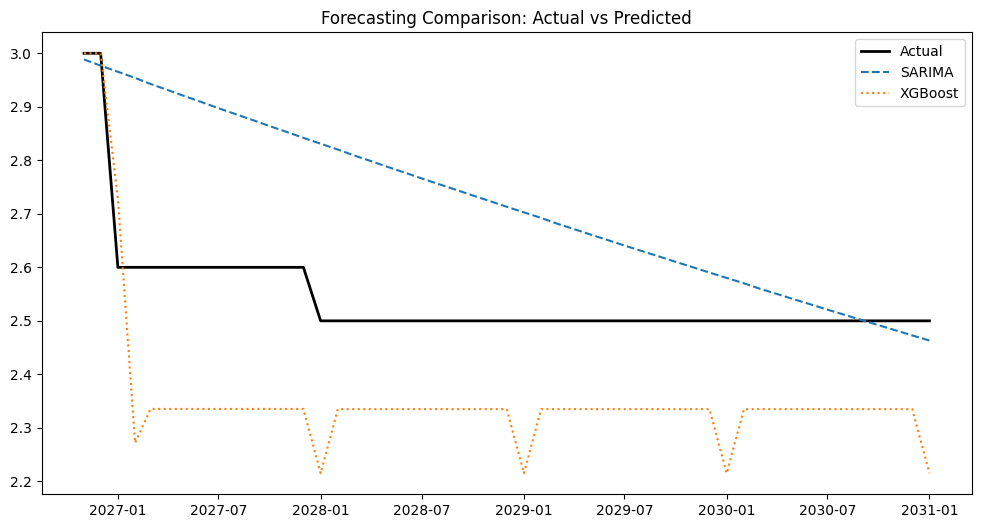

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(test_df['date'], y_test, label='Actual', color='black', linewidth=2)
plt.plot(test_df['date'], pred_sarima, label='SARIMA', linestyle='--')
plt.plot(test_df['date'], pred_xgb, label='XGBoost', linestyle=':')
plt.title("Forecasting Comparison: Actual vs Predicted")
plt.legend()
plt.show()